In [1]:
!pip install opencv-python imutils numpy matplotlib

In [6]:
import cv2
import numpy as np
import imutils
from imutils import contours
from imutils import perspective
import matplotlib.pyplot as plt

In [3]:
from google.colab import files
uploaded = files.upload()

Saving image.jpg to image.jpg


(np.float64(-0.5), np.float64(599.5), np.float64(379.5), np.float64(-0.5))

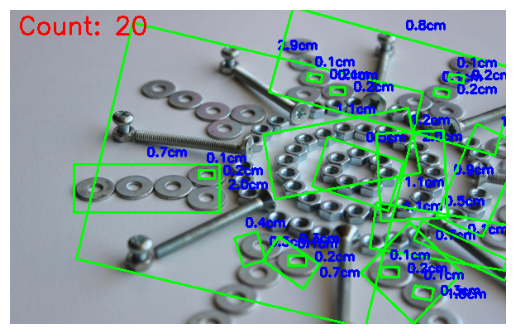

In [7]:
# Load image
image = cv2.imread(list(uploaded.keys())[0])
orig = image.copy()

# Resize for better processing
image = imutils.resize(image, width=600)

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur + Edge detection
blur = cv2.GaussianBlur(gray, (7, 7), 0)
edged = cv2.Canny(blur, 50, 100)

# Dilate + Erode to clean edges
edged = cv2.dilate(edged, None, iterations=1)
edged = cv2.erode(edged, None, iterations=1)

# Find contours
cnts = cv2.findContours(edged.copy(), cv2.RETR_EXTERNAL,
                        cv2.CHAIN_APPROX_SIMPLE)
cnts = imutils.grab_contours(cnts)

# Sort contours left-to-right
(cnts, _) = contours.sort_contours(cnts)

# Initialize variables
pixelsPerMetric = None
object_count = 0

# Loop over contours
for c in cnts:
    if cv2.contourArea(c) < 100:
        continue

    object_count += 1

    # Bounding box
    box = cv2.minAreaRect(c)
    box = cv2.boxPoints(box)
    box = np.array(box, dtype="int")

    # Order points
    box = imutils.perspective.order_points(box)

    # Draw contour
    cv2.drawContours(image, [box.astype("int")], -1, (0, 255, 0), 2)

    # Midpoints
    (tl, tr, br, bl) = box
    mid_top = ((tl[0] + tr[0]) // 2, (tl[1] + tr[1]) // 2)
    mid_bottom = ((bl[0] + br[0]) // 2, (bl[1] + bl[1]) // 2)
    mid_left = ((tl[0] + bl[0]) // 2, (tl[1] + bl[1]) // 2)
    mid_right = ((tr[0] + br[0]) // 2, (tr[1] + br[1]) // 2)

    # Distances
    dA = np.linalg.norm(np.array(mid_top) - np.array(mid_bottom))
    dB = np.linalg.norm(np.array(mid_left) - np.array(mid_right))

    # Assume first object width = known reference (e.g., 2 cm)
    if pixelsPerMetric is None:
        pixelsPerMetric = dB / 2.0  # change 2.0 based on real object size

    # Compute size
    dimA = dA / pixelsPerMetric
    dimB = dB / pixelsPerMetric

    # Display measurements
    cv2.putText(image, "{:.1f}cm".format(dimA),
                (int(mid_top[0]), int(mid_top[1] - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    cv2.putText(image, "{:.1f}cm".format(dimB),
                (int(mid_right[0] + 10), int(mid_right[1])),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

# Show object count
cv2.putText(image, f"Count: {object_count}", (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

# Display result
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")